# Exploring U.S. Video Game Sales Across Consoles (2004–2010)

**Shaurya Ghai, Granth Bangard, Aarush Bhardwaj**

Part 1 of 3 — Exploratory Data Analysis & Visualization

## 1. Introduction

### Research Question
How do U.S. video game sales (in millions) differ across gaming consoles in this dataset?

### Motivation
We focused on this question because most of us grew up playing Sony and Nintendo titles, which made us curious about how different consoles actually compared in commercial terms. A game publisher or developer could use this kind of analysis to understand which platforms tended to produce higher-selling titles, and which had more unpredictable outcomes.

### Contextual Importance
Comparing per-console sales helps contextualize platform performance during a pivotal era in gaming. Understanding which consoles produced higher-selling titles on average — versus which simply had more titles — is a meaningful distinction for anyone analyzing the industry's commercial history.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('video_games.csv', encoding='unicode-escape')
print(df.shape)
df.head()

(1770, 166)


,Console,Title,US Sales (millions),Block4,Block2,Block1,Block0.5,YearReleased,2004,2005,...,Tricks,Volleyball,Wakeboarding,Wrestling,FirstPerson,Platform,Isometric,SideScrolling,TopDown,ThirdPerson
0,Nintendo DS,Super Mario 64 DS,4.69,1,1,1,1,2004,1,0,...,0,0,0,0,0,1,0,0,0,1
1,Sony PSP,Lumines: Puzzle Fusion,0.56,0,0,0,1,2004,1,0,...,0,0,0,0,0,0,0,0,0,0
2,Nintendo DS,WarioWare Touched!,0.54,0,0,0,1,2004,1,0,...,0,0,0,0,0,1,1,1,1,1
3,Sony PSP,Hot Shots Golf: Open Tee,0.49,0,0,0,0,2004,1,0,...,0,0,0,0,0,0,0,0,0,1
4,Nintendo DS,Spider-Man 2,0.45,0,0,0,0,2004,1,0,...,0,0,0,0,0,1,0,1,0,1


## 2. Dataset Overview

**Source:** University of Portsmouth Research Portal, curated by Dr. Joe Cox. Originally downloaded from https://researchportal.port.ac.uk/en/datasets/video-games-dataset

**Contents:** 1,770 video game titles released in the U.S. between 2004–2010, with 166 variables covering console, sales figures, release year, and gameplay features.

**Unit of observation:** Each row represents a single game title released on a specific console.

**Variables of interest:**
- `Console` — categorical: the gaming platform (X360, Nintendo DS, PlayStation 3, Sony PSP, Nintendo Wii)
- `US Sales (millions)` — quantitative: U.S. sales in millions of copies

**Limitations:** The dataset covers only U.S. sales and only commercially notable titles from 2004–2010. Smaller indie games are likely absent, and global sales are not captured. Results reflect this specific dataset and era, not the current market.

In [2]:
df['Console'].value_counts()

X360             437
Nintendo DS      418
PlayStation 3    312
Sony PSP         307
Nintendo Wii     296
Name: Console, dtype: int64

In [3]:
df['YearReleased'].value_counts()

2007    465
2008    444
2009    321
2006    294
2005    150
2010     73
2004     23
Name: YearReleased, dtype: int64

## 3. Data Cleaning

In [4]:
# Check for missing values
print('Total missing values:', df.isna().sum().sum())
print()
print('Dtypes for variables of interest:')
print(df[['Console', 'US Sales (millions)']].dtypes)

Total missing values: 0

Dtypes for variables of interest:
Console                 object
US Sales (millions)    float64
dtype: object


In [5]:
# Check unique console values
print('Console categories:', df['Console'].unique())

Console categories: ['Nintendo DS' 'Sony PSP' 'X360' 'Nintendo Wii' 'PlayStation 3']


**Cleaning decisions:**
- No missing values found for either variable of interest (0 rows dropped)
- Console contains exactly 5 categories with no placeholder values
- US Sales distribution is right-skewed but all values are positive and plausible for the era — no impossible values found, no rows dropped

In [6]:
df['US Sales (millions)'].describe()

count    1770.000000
mean        0.479785
std         1.064915
min         0.010000
25%         0.090000
50%         0.190000
75%         0.450000
max        14.660000
Name: US Sales (millions), dtype: float64

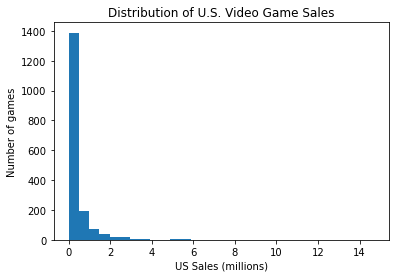

In [7]:
histogram = df['US Sales (millions)'].plot.hist(bins=30)
histogram.set_xlabel('US Sales (millions)')
histogram.set_ylabel('Number of games')
histogram.set_title('Distribution of U.S. Video Game Sales')
plt.show()

The distribution is strongly right-skewed: most games sold under 0.5M copies, while a small number of blockbuster titles pulled the mean well above the median.

## 4. Exploratory Analysis

### Research Question: How do U.S. sales differ across consoles?

<Figure size 1008x360 with 0 Axes>

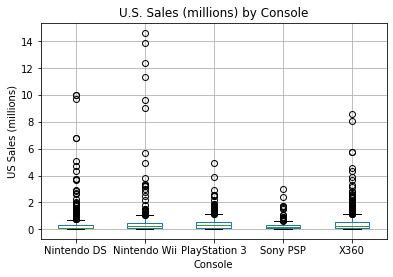

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
df.boxplot(column='US Sales (millions)', by='Console')
plt.suptitle('')
plt.title('U.S. Sales (millions) by Console')
plt.xlabel('Console')
plt.ylabel('US Sales (millions)')
plt.show()

<Figure size 1008x360 with 0 Axes>

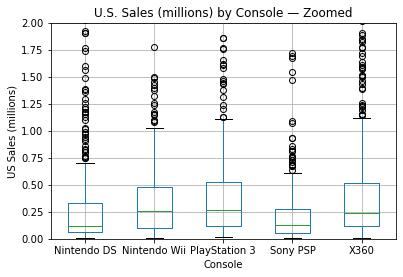

In [9]:
# Zoomed view to compare quartiles without extreme outliers dominating
plt.figure(figsize=(14, 5))
ax = df.boxplot(column='US Sales (millions)', by='Console')
ax.set_ylim(0, 2)
plt.title('U.S. Sales (millions) by Console — Zoomed')
plt.suptitle('')
plt.xlabel('Console')
plt.ylabel('US Sales (millions)')
plt.show()

                  sum  median      mean
Console                                
Nintendo DS    187.24    0.12  0.447943
Nintendo Wii   204.57    0.26  0.691115
PlayStation 3  142.76    0.27  0.457564
Sony PSP        73.78    0.13  0.240326
X360           240.87    0.24  0.551190


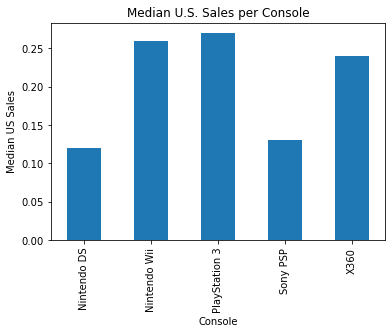

In [10]:
df_consoles = df.groupby('Console')['US Sales (millions)'].agg(['sum', 'median', 'mean'])
print(df_consoles)

df_consoles['median'].plot.bar(
    xlabel='Console',
    ylabel='Median US Sales',
    title='Median U.S. Sales per Console'
)
plt.show()

### Findings

The boxplots show strong right-skew for every console — the typical game sold relatively little, while a small number of blockbusters created extreme outliers across all platforms.

**Median sales comparison (most representative of the typical game):**
- PlayStation 3 (~0.27M) and Nintendo Wii (~0.26M) had the highest medians
- X360 (~0.24M) was close behind
- Sony PSP (~0.13M) and Nintendo DS (~0.12M) had noticeably lower medians

**Total sales tell a different story:** X360 leads in total sales (~240M), but this is partly because X360 and DS have more game titles in the dataset — more entries naturally inflate the sum even if per-game sales are lower.

**Key insight:** Means are higher than medians for every console, confirming that a few high-selling titles pull averages up significantly. Median is the more honest measure of typical game performance.

## 5. Conclusion

### Summary
We explored U.S. video game sales across five consoles from 2004–2010. Using boxplots and summary statistics, we found that PlayStation 3 and Nintendo Wii produced the highest median per-game sales, while X360 dominated in total volume partly due to having more titles in the dataset.

### Limitations
- U.S. only; global sales data would change the picture significantly
- Covers only commercially notable titles; indie games are absent
- Data ends at 2010; does not reflect digital distribution era
- X360 and DS have more entries, inflating their total sales comparisons

### Next Steps
Exploring whether console differences in sales changed year over year, and whether focusing on per-game averages (controlling for number of titles per console) changes the ranking. See Notebooks 2 and 3 for inference and modeling on this dataset.